![jupyter](img/itq-logo.png )

## Exámen Práctico - Segundo Parcial

![jupyter](img/python-logo.png )

*Lesly Noemi Becerra Campaña*

#### 0) Cargar una de las imágenes histológicas

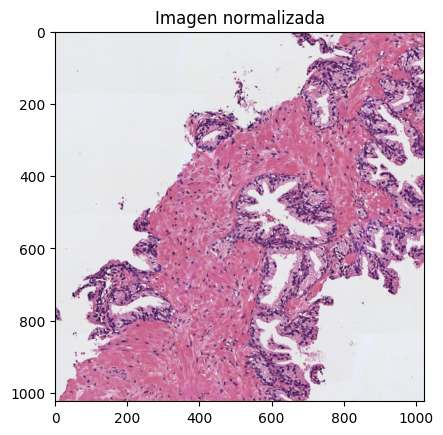

In [56]:
from skimage import io
import numpy as np
import cv2
import matplotlib.pyplot as plt
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
imagen1 = io.imread('img/histo_1.jpg')
rgb = imagen1.copy()
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
img_normalizada = rgb.astype('float') / 255
# Visualizar la imagen
plt.imshow(img_normalizada)
plt.title('Imagen normalizada')
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

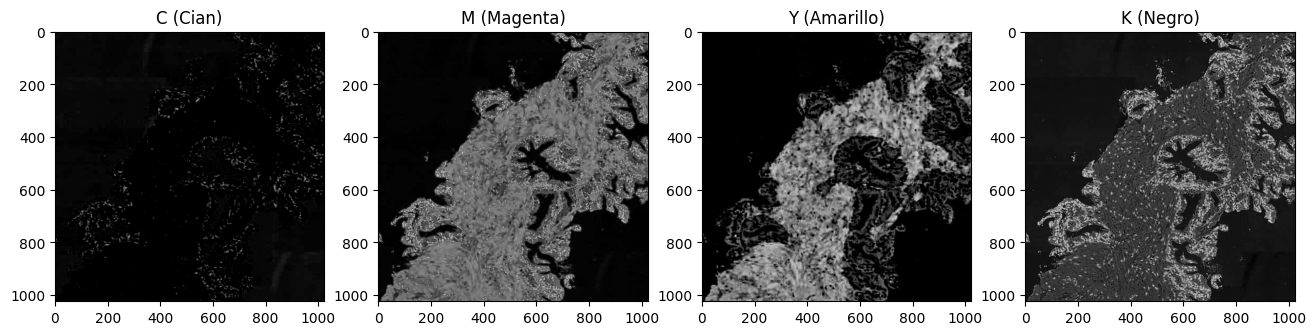

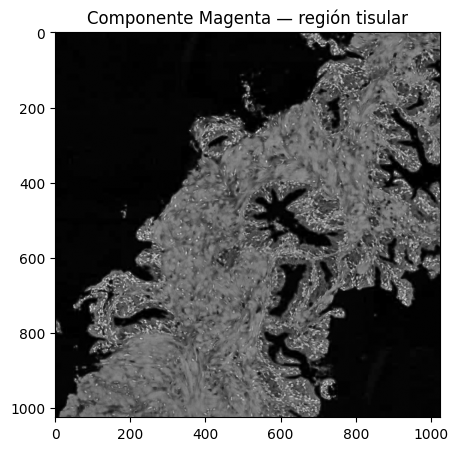

In [63]:
R, G, B = img_normalizada[:,:,0], img_normalizada[:,:,1], img_normalizada[:,:,2]

K = 1 - np.max(img_normalizada, axis=2)
#Tambien podría utilizar np.where: M = np.where(K < 1, (1 - G_prima - K) / (1 - K), 0)
C = (1 - R - K) / (1 - K + 1e-8)
M = (1 - G - K) / (1 - K + 1e-8)
Y = (1 - B - K) / (1 - K + 1e-8)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(C, cmap='gray')
axes[0].set_title('C (Cian)')

axes[1].imshow(M, cmap='gray')
axes[1].set_title('M (Magenta)')

axes[2].imshow(Y, cmap='gray')
axes[2].set_title('Y (Amarillo)')

axes[3].imshow(K, cmap='gray')
axes[3].set_title('K (Negro)')

plt.show()

# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
Magenta = M
# Visualizar la imagen del canal magenta
plt.figure(figsize=(6, 5))
plt.imshow(Magenta, cmap='gray')
plt.title('Componente Magenta — región tisular')
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

[0 1]


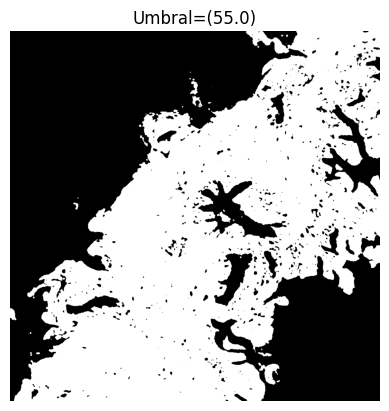

In [64]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
M_float = np.clip(M, 0, 1)
M_uint8 = (M_float * 255).astype('uint8')

M_suavizado = cv2.GaussianBlur(M_uint8, (5, 5), 0)

# threshold_otsu analiza el histograma y devuelve el mejor umbral
t, mask = cv2.threshold(M_suavizado, 0, 1, cv2.THRESH_OTSU)
print(np.unique(mask))

# Visualizar la máscara resultante
plt.imshow(mask, cmap='gray')
plt.title(f'Umbral=({t})')
plt.axis('off')
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

C:\Users\HP\AppData\Local\Temp\ipykernel_14184\3101538051.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_limpia = morphology.remove_small_objects(mask_bool, min_size=300)


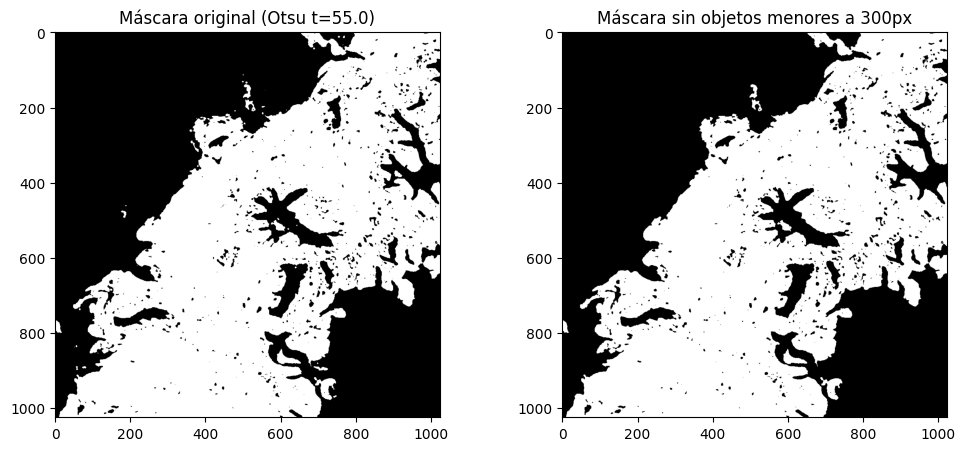

In [75]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
from skimage import morphology

# remove_small_objects necesita la máscara en formato booleano
mask_bool = mask.astype(bool)

mask_limpia = morphology.remove_small_objects(mask_bool, min_size=300)

# Visualizaer la máscara resultante
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(mask, cmap='gray')
axes[0].set_title(f'Máscara original (Otsu t={t})')

axes[1].imshow(mask_limpia, cmap='gray')
axes[1].set_title('Máscara sin objetos menores a 300px')

plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [74]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos
# y el resto de la imagen negra. Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero
# se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

#### 5) Rellenar los objetos de los lúmenes

In [ ]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [ ]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

#### 7) Identificar y cropear el lumen más grande

In [ ]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [ ]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad